# Embedding caching for an agent's long-term memory

An **embedding cache** stores the vector a model produced for a piece of text, under a key that
describes everything that determined that vector: the exact text, the model and its revision, and
the settings the model ran with. The next time the agent needs a vector for the same text under the
same settings, it reads the stored vector instead of running the model again.

This notebook builds one for a realistic workload: a **coding agent that keeps a long-term memory of
the GitHub issues it has worked on** and rebuilds its retrieval index every time it starts. Most of
those memories have not changed since the previous start-up, so most of that encoding is repeated work.

**What you will build**

- An Oracle AI Database table that stores vectors under a content-and-configuration key, shared by every agent worker.
- A batched read-through cache: one query looks up every key, and the model encodes only the misses, in one batch.
- The agent's start-up re-index, measured with no cache, with a cold cache, with a warm cache, after a few memories are edited, and after one model setting changes.
- Retrieval over the cached vectors through an Oracle HNSW vector index (checked against an exact search), a cross-encoder rerank, and one Claude call that uses what was retrieved.

**What you need**

- An Anthropic API key. The notebook makes a single Claude call.
- A dedicated schema in Oracle AI Database 23ai or later, for the native `VECTOR` data type.
- Internet access on the first run, to download two small open-source models from Hugging Face (about 90 MB each) and a public dataset.

### Install the notebook packages

Use a **Python 3.12** kernel. Open this notebook from the `cache_techniques` folder so `requirements.txt` is available. Run the next cell before Part 1: **%pip** installs into the Python environment used by this notebook's active kernel.

`requirements.txt` installs **anthropic** for Claude, **sentence-transformers** for the open-source Hugging Face embedding model and reranker (it brings PyTorch and transformers), **oracledb** and **langchain-oracledb** for Oracle AI Database, **tavily-python** for web search, **pandas**, **pyarrow** and **huggingface_hub** for reading public Hugging Face datasets, and **numpy** and **matplotlib** for measurements and charts. It also installs JupyterLab, plus nbformat and nbclient, which `tests/run_notebooks.py` uses to run a notebook end to end.

After the first installation finishes, **restart the kernel**, then run the Parts in order. Installation needs internet access; it does not need your API keys.

In [1]:
# Install packages into this notebook's active Python kernel.
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Part 1 · How embedding caching works

## 1.1 · The idea

An embedding model is a deterministic function. Given the same model files, the same settings and the
same text, it returns the same vector (bit for bit on the same hardware and library versions, and to
within floating-point rounding elsewhere). Computing that vector still costs something:

- A **local model** spends CPU or GPU time on tokenisation and a forward pass through the network. For
  the small model in this notebook that is a few milliseconds per text, which adds up when an agent
  re-encodes thousands of memories at every start-up.
- A **hosted embedding API** charges per input token, adds a network round trip and enforces rate
  limits, so every repeated request costs money as well as time.

Agents repeat embedding work all the time: they rebuild a memory index after a restart, re-ingest
documents that did not change, embed the same query text on several turns of a loop, and run several
workers that each index the same store. An embedding cache turns that repeated work into lookups.

What the cache reuses is deliberately narrow, which is what makes it safe. It stores **vectors**, never
answers. It skips the model's forward pass; it does not skip retrieval, ranking or generation. It also
says nothing about whether the text behind a vector is still true: that is the job of the memory itself.

## 1.2 · The request flow

The diagram shows one re-index of the agent's memory with the cache in place. The indexer is part of the
agent application; the embedding cache (`EC_EMBEDDING_CACHE`) and the searchable memory index
(`EC_AGENT_MEMORY`) are tables in Oracle AI Database; the embedding model runs locally.

**Figure · Embedding cache request flow**

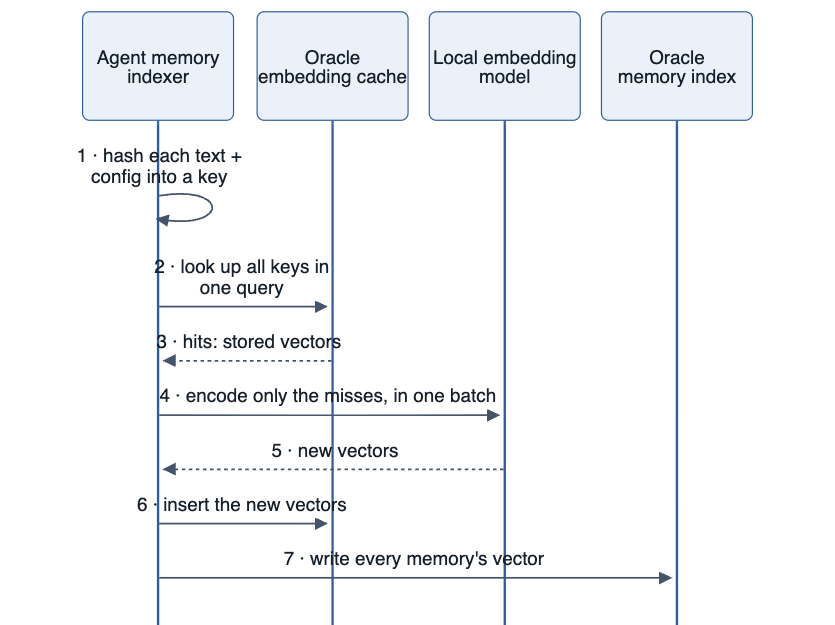

<details><summary>Mermaid source</summary>

```mermaid
sequenceDiagram
    participant A as Agent memory indexer
    participant C as Oracle<br/>embedding cache
    participant M as Local embedding model
    participant I as Oracle<br/>memory index
    A->>A: 1 · hash each text + config into a key
    A->>C: 2 · look up all keys in one query
    C-->>A: 3 · hits: stored vectors
    A->>M: 4 · encode only the misses, in one batch
    M-->>A: 5 · new vectors
    A->>C: 6 · insert the new vectors
    A->>I: 7 · write every memory's vector
```

</details>

1. **Hash.** For every text the indexer computes a key: a SHA-256 hash over the text and the encoder
   configuration. Hashing takes microseconds and involves no model.
2. **Look up in one batch.** All keys go to Oracle in a single query. One round trip for a hundred keys
   costs about the same as one round trip for a single key, so batching is what makes the cache fast.
3. **Hits.** Rows that exist are hits; their stored vectors are used as they are.
4. **Encode the misses together.** Texts whose keys were not found go to the model in one batch. A batched
   forward pass is far cheaper per text than one model call per text.
5. **New vectors.** The model returns one vector per missed text.
6. **Insert.** The new vectors are stored under their keys, so the next start-up, or another worker,
   finds them.
7. **Index.** Hits and new vectors, back in their original order, are written to the agent's memory
   index, which retrieval searches.

## 1.3 · What makes two requests the same

The key must change whenever the vector would change. Leave something out and two different vectors
share one entry; put too much in and identical vectors are stored twice. For a sentence-transformers
model the vector depends on:

| Part of the key | Why it belongs there |
|---|---|
| Model name | Different models place text in different, incompatible vector spaces. |
| Model revision | A retrained or re-exported model under the same name produces different vectors. The revision is a commit hash in the model repository. |
| Maximum sequence length | The model in this notebook reads at most 256 word pieces and silently ignores the rest. Lower the limit to 128 and every long text gets a different vector. |
| Normalisation | Whether vectors are scaled to unit length. This model normalises inside the network, so the flag happens not to change its output, but for most models it does. |
| Prompt or input role | Models such as E5, BGE and Nomic prepend an instruction such as `query:` or `search_document:`, so one text has a different vector per role. MiniLM uses none, so the prompt is `None`. |
| Output dimensions | Matryoshka models can be truncated to 256 or 512 dimensions; each size is a different vector. |
| SHA-256 of the exact text | The text itself. Hashing keeps the key short and fixed-length. |
| Namespace | The agent deployment that owns the entry. |

**Canonicalisation.** The key is a hash of a JSON object serialised with sorted keys and fixed
separators, so the same configuration always produces the same bytes. If you normalise text before
hashing (trimming whitespace, Unicode NFC), embed the normalised text too: the key must describe the
input the model actually read.

**Scope.** Vectors of public text can be shared widely. Vectors of private text can be inverted to
recover a surprising amount of the original, and a stored hash shows that a text was seen, so scope a
private cache to its owner exactly as you scope the memory itself.

## 1.4 · Freshness, expiry and invalidation

A vector does not go stale with time. It becomes wrong only when its text or its configuration changes,
and with a content-addressed key both changes produce a **new key**: the old entry is simply never
looked up again. No invalidation code is needed for correctness.

What remains is housekeeping:

- **Orphans.** An edited memory leaves its previous vector behind. Evict entries that have not been read
  for a while, or delete by key when the memory changes.
- **Model upgrades.** A new model or revision starts a new key space. Re-index everything under the new
  configuration and never mix vectors from two models in one index: distances across vector spaces are
  meaningless.
- **Forgetting.** When a user asks the agent to forget something, delete the memory *and* its cached
  vectors. A vector is computed from the text and can leak it.

A time-to-live on this cache is a storage policy, not a correctness policy.

## 1.5 · When it helps and when it hurts

**It helps when text repeats:** start-up re-indexing, re-ingesting mostly unchanged documents, query text
embedded on several loop turns, and several workers indexing one store. It helps most with hosted
embedding APIs, where every avoided request saves money and rate-limit budget, and with large models,
where a forward pass costs far more than a database read.

**It does nothing, or hurts, when:**

- Text never repeats. Every lookup is a miss, so you pay a round trip and an insert on top of encoding.
- The model is tiny and the texts are short. A database round trip can cost more than the forward
  pass; measure before assuming a win.
- The key is incomplete. Two configurations then share entries and the index silently mixes vector
  spaces. This is the one failure that produces *wrong* results rather than slow ones.
- Storage grows without limit. Every distinct text and configuration adds a row that must eventually be
  evicted.

### Takeaways

- An embedding cache memoises a deterministic function: it stores vectors, never answers or judgements.
- The key is everything that changes the vector: model, revision, settings, prompt, dimensions and the exact text.
- Content-addressed keys make edits and model upgrades safe without any invalidation code.
- Batch both sides: one lookup query and one forward pass per batch of misses.
- Forgetting a memory includes purging its cached vectors.

# Part 2 · The use case: a coding agent that re-indexes its memory

## 2.1 · The scenario

A coding agent works on the Django codebase. Every GitHub issue it has investigated is kept as an
episodic memory: the issue text, plus any notes the agent added while working on it. When a new task
arrives, the agent searches those memories for related past issues: a similar bug, the same subsystem,
a fix that touched the same code.

Searching needs a vector index, and the agent process rebuilds that index whenever it starts: after a
deploy, after a crash, when a new worker joins, or when the memory store reports changes. Without a
cache every start-up re-encodes every memory, although only a handful changed since the last one.

The memories here are real. They are 100 Django issues from
[SWE-bench Lite](https://huggingface.co/datasets/SWE-bench/SWE-bench_Lite), a public dataset of GitHub
issues from popular Python projects. The new task is another real Django issue that is not among them.

## 2.2 · Where the cache sits in the agent's memory

- **Episodic memory**, the issues the agent worked on and its notes about them, is the memory of record:
  text in a durable store.
- The **vector index** is derived data: a searchable view of episodic memory that can always be rebuilt
  from the text.
- The **embedding cache** is one step further removed: a memo of the encoder that produced the index.
  Deleting it loses nothing but compute time.
- **Working memory**, the current task and the memories retrieved for it, passes through the same cache
  when the task text is embedded as a query.
- **Semantic and procedural memory** (facts about the codebase, how-to instructions) would use the same
  cache whenever they are retrieved by vector.

Because the cache is never the memory of record, it can be shared, evicted or wiped without the agent
forgetting anything. The reverse does not hold: when a memory is deleted, its cached vectors must go too.

**Figure · The coding agent's memory with the embedding cache in place**

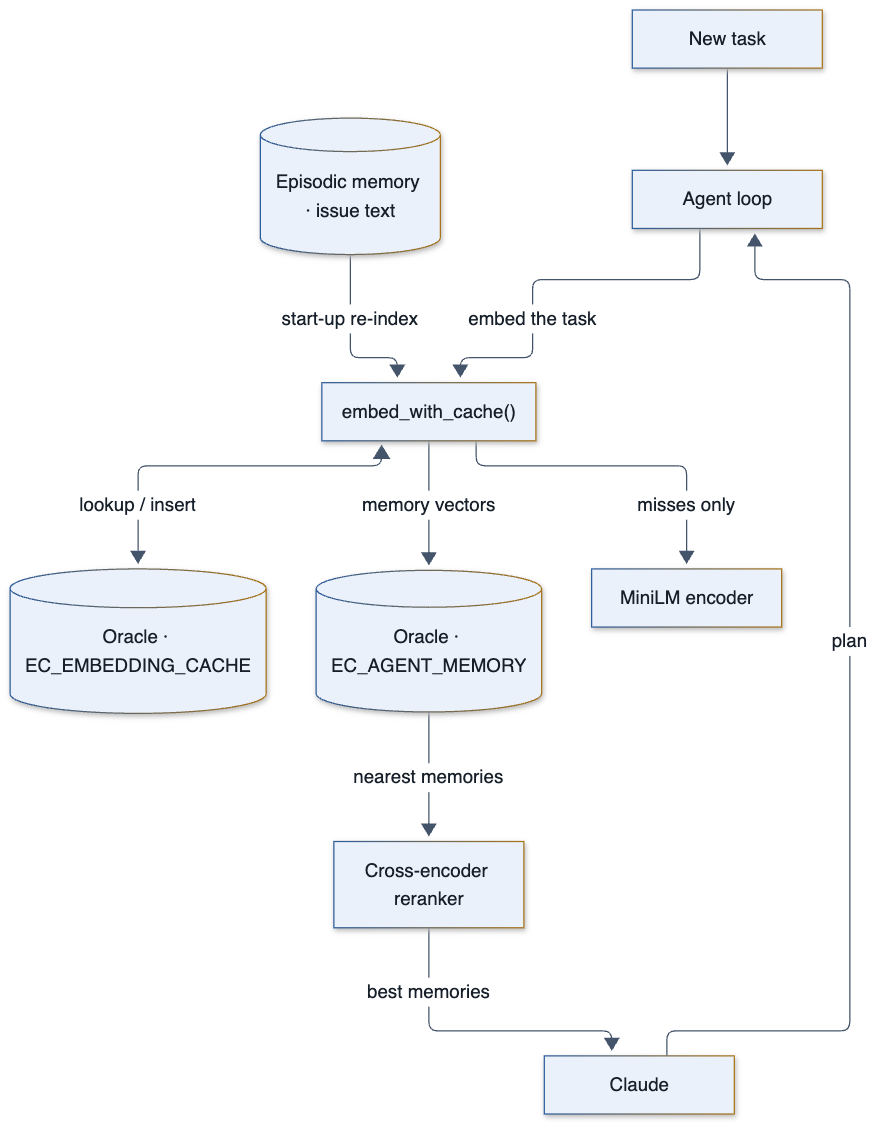

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    Task["New task"] --> Loop["Agent loop"]
    Store[("Episodic memory · issue text")] -->|"start-up re-index"| Embed["embed_with_cache()"]
    Loop -->|"embed the task"| Embed
    Embed <-->|"lookup / insert"| Cache[("Oracle · EC_EMBEDDING_CACHE")]
    Embed -->|"misses only"| Model["MiniLM encoder"]
    Embed -->|"memory vectors"| Index[("Oracle · EC_AGENT_MEMORY")]
    Index -->|"nearest memories"| Rerank["Cross-encoder reranker"]
    Rerank -->|"best memories"| Claude["Claude"]
    Claude -->|"plan"| Loop
```

</details>

The start-up path (left) and the task path (top) share one function, `embed_with_cache()`, so both
benefit from the cache. Retrieval then works on vectors that may have come from the cache or from the
model; the rest of the agent cannot tell the difference, which is exactly the point.

### Takeaways

- The issue text is the memory; vectors and cached vectors are rebuildable views of it.
- Re-indexing at start-up is the repeated work; most memories are unchanged between start-ups.
- The same cache serves memory vectors and query vectors.

# Part 3 · Set up

## 3.1 · Import the libraries

- `hashlib`, `json` and `uuid` build cache keys and a namespace for this run; `array` converts numpy
  vectors into the `array.array("f")` form that python-oracledb binds to a `VECTOR` column.
- `oracledb` talks to Oracle AI Database. `fetch_lobs = False` returns `CLOB` columns as ordinary Python
  strings, which is convenient for issue texts of a few kilobytes.
- `SentenceTransformer` runs the embedding model and `CrossEncoder` the reranker, both locally.
- `TOKENIZERS_PARALLELISM=false`, the transformers log level and one warning filter keep library notices
  (tokenizer forks, a missing notebook progress-bar widget, a renamed sentence-transformers method) out
  of the outputs. None of them affects results.

In [2]:
import array, hashlib, json, os, time, uuid, warnings
from getpass import getpass

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
warnings.filterwarnings(
    "ignore", message="IProgress not found|The `get_sentence_embedding_dimension`"
)

import matplotlib.pyplot as plt
import numpy as np
import oracledb
import pandas as pd
from anthropic import Anthropic
from IPython.display import display
from sentence_transformers import CrossEncoder, SentenceTransformer
from transformers.utils import logging as transformers_logging

transformers_logging.set_verbosity_error()
oracledb.defaults.fetch_lobs = False

## 3.2 · Connect the clients and load the models

The next cells create everything the agent needs: a safe way to read keys, the Claude client with a
ledger that prices every call, the Oracle connection, and the two open-source models.

### Read private keys safely

`secret()` asks for a key with `getpass`, so the value is never echoed into the notebook
or saved with its outputs. Automated runs can set `NOTEBOOK_USE_ENV_KEYS=1` to read the
same name from an environment variable instead. An empty value stops the notebook early
with a clear error rather than failing later inside a provider call.

In [3]:
def secret(name):
    """Return a private key from a hidden prompt, or from the environment in automated runs."""
    if os.getenv("NOTEBOOK_USE_ENV_KEYS") == "1":
        value = os.getenv(name, "")
    else:
        value = getpass(f"Enter {name}: ")
    if not value.strip():
        raise ValueError(f"{name} is required.")
    return value.strip()

### Price every Claude call from reported usage

Every response from the Anthropic API reports how many tokens it processed. The prices below
are the published list prices for Claude Opus 5.5 (USD per million tokens, checked on
2026-10-03). Each counter is priced separately:

- `input`: ordinary prompt tokens.
- `cache_write`: prompt tokens written to Anthropic's prompt cache (1.25× input).
- `cache_read`: prompt tokens read back from that cache (0.05× input on Opus 5.5).
- `output`: generated tokens, the most expensive counter.

`LLM_CALLS` is a ledger: one row per real request, so every cost in this notebook can be
traced back to an actual API response. These are list-price estimates, not an invoice.

In [4]:
MODEL = "claude-opus-5-5"
PRICE = {"input": 4.00, "cache_write": 5.00, "cache_read": 0.20, "output": 20.00}
LLM_CALLS = []


def llm_cost(usage):
    """Price one response from the token counters the API returned."""
    tokens = {
        "input": usage.input_tokens,
        "cache_write": usage.cache_creation_input_tokens or 0,
        "cache_read": usage.cache_read_input_tokens or 0,
        "output": usage.output_tokens,
    }
    return tokens, sum(tokens[k] * PRICE[k] for k in tokens) / 1_000_000

### One function for every model call

`ask_claude()` sends a single request with the raw Anthropic SDK. `system` is either a plain
string or a list of content blocks (the list form is what lets a block carry a prompt-cache
breakpoint). `effort="low"` asks the model for a direct answer, which keeps latency and
output tokens down. The function records latency, the four token counters and the estimated
cost in `LLM_CALLS`, then returns only the visible text.

In [5]:
def ask_claude(system, user, max_tokens=1024):
    """Send one request, record latency, tokens and cost, and return the answer text."""
    started = time.perf_counter()
    response = claude.messages.create(
        model=MODEL,
        max_tokens=max_tokens,
        system=system,
        messages=[{"role": "user", "content": user}],
        output_config={"effort": "low"},
    )
    tokens, usd = llm_cost(response.usage)
    seconds = time.perf_counter() - started
    LLM_CALLS.append({"seconds": seconds, **tokens, "usd": usd})
    return "".join(b.text for b in response.content if b.type == "text")

Create the client. The key is read with `secret()`; the client object keeps it in memory
only. A timeout and two retries keep a slow network from hanging the notebook.

In [6]:
claude = Anthropic(api_key=secret("ANTHROPIC_API_KEY"), timeout=120, max_retries=2)

### Connect to Oracle AI Database

The cache tables live in a **dedicated application schema**. `oracle_connection()` reads
`ORACLE_USER`, `ORACLE_PASSWORD` and `ORACLE_DSN` from the environment and prompts for any
that are missing (the password prompt is hidden). It refuses `SYS` and `SYSTEM`: an
application cache should never run with administrator privileges. The schema needs
`CREATE TABLE` and a tablespace quota; vector features need Oracle AI Database 23ai or later.

In [7]:
def oracle_connection():
    """Connect to a dedicated schema; administrator accounts are refused."""
    user = os.getenv("ORACLE_USER") or input("Oracle user: ").strip()
    password = os.getenv("ORACLE_PASSWORD") or getpass("Oracle password: ")
    dsn = os.getenv("ORACLE_DSN") or input("Oracle DSN (host:port/service): ").strip()
    if user.lower() in {"sys", "system"}:
        raise ValueError("Use a dedicated application schema.")
    return oracledb.connect(user=user, password=password, dsn=dsn)


conn = oracle_connection()
print("Connected to Oracle", conn.version)

Connected to Oracle 23.26.2.0.0


`create_if_missing()` makes the DDL in this notebook safe to re-run. Oracle raises
`ORA-00955` when an object name already exists; only that error is ignored. Anything else,
such as a missing privilege or an exhausted vector memory pool, is raised so you can see it.

In [8]:
def create_if_missing(sql):
    """Run DDL, ignoring only 'name is already used by an existing object'."""
    with conn.cursor() as cursor:
        try:
            cursor.execute(sql)
        except oracledb.DatabaseError as error:
            if error.args[0].code != 955:
                raise

### Load the open-source embedding model

Embeddings come from [`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), a small
open-source model from Hugging Face that runs locally on the CPU. It maps text to a
384-dimensional vector. Pinning the **revision** (a commit hash in the model repository)
matters for caching: if the model files change, the vectors change, and every stored vector
must be treated as stale. The first run downloads about 90 MB; later runs load from the
local Hugging Face cache. No API key is needed and no text leaves your machine.

In [9]:
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
EMBED_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
encoder = SentenceTransformer(EMBED_MODEL, revision=EMBED_REVISION, device="cpu")
EMBED_DIM = encoder.get_embedding_dimension()
print(EMBED_MODEL, "→", EMBED_DIM, "dimensions")

sentence-transformers/all-MiniLM-L6-v2 → 384 dimensions


### Load the open-source reranker

A **reranker** is a cross-encoder: it reads two texts *together* and returns one relevance
score, which is slower than comparing two precomputed vectors but much better at telling
"same question" from "similar words". This notebook uses
[`cross-encoder/ms-marco-MiniLM-L-6-v2`](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2), also local and pinned to a
revision. Its scores are unbounded logits: higher means more relevant, and values above
zero mean the model leans towards "relevant".

In [10]:
RERANK_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
RERANK_REVISION = "233902d25c440f23af6f7d6e94d2946bac0bee0a"
reranker = CrossEncoder(RERANK_MODEL, revision=RERANK_REVISION, device="cpu")
print("Reranker ready:", RERANK_MODEL)

Reranker ready: cross-encoder/ms-marco-MiniLM-L-6-v2


## 3.3 · Load the agent's memories

SWE-bench Lite is read straight from Hugging Face with pandas. The URL pins a dataset **revision** (a
commit hash), so the rows are identical on every run. Only the three columns this notebook needs are
read: `instance_id` (a stable id such as `django__django-11099`), `repo` (the GitHub repository) and
`problem_statement` (the issue text exactly as its reporter wrote it).

**What to watch:** 300 real issues from a dozen Python repositories. The display shortens long issue
text to keep the table readable; the DataFrame itself holds the full text.

In [11]:
SWE_BENCH = "hf://datasets/SWE-bench/SWE-bench_Lite@b0dde1093fe417d83b7184254edf8199c1f0dff5/data/test-00000-of-00001.parquet"
issues = pd.read_parquet(
    SWE_BENCH, columns=["instance_id", "repo", "problem_statement"]
)

print(issues.shape[0], "issues from", issues.repo.nunique(), "repositories")
with pd.option_context("display.max_colwidth", 110):
    display(issues.head(10))

300 issues from 12 repositories


,instance_id,repo,problem_statement
0,astropy__astropy-12907,astropy/astropy,Modeling's `separability_matrix` does not compute separability correctly for nested CompoundModels\nConsid...
1,astropy__astropy-14182,astropy/astropy,Please support header rows in RestructuredText output\n### Description\r\n\r\nIt would be great if the fol...
2,astropy__astropy-14365,astropy/astropy,ascii.qdp Table format assumes QDP commands are upper case\n### Description\n\nascii.qdp assumes that comm...
3,astropy__astropy-14995,astropy/astropy,"In v5.3, NDDataRef mask propagation fails when one of the operand does not have a mask\n### Description\n\..."
4,astropy__astropy-6938,astropy/astropy,Possible bug in io.fits related to D exponents\nI came across the following code in ``fitsrec.py``:\r\n\r\...
5,astropy__astropy-7746,astropy/astropy,Issue when passing empty lists/arrays to WCS transformations\nThe following should not fail but instead sh...
6,django__django-10914,django/django,"Set default FILE_UPLOAD_PERMISSION to 0o644.\nDescription\n\t\nHello,\nAs far as I can see, the ​File Uplo..."
7,django__django-10924,django/django,Allow FilePathField path to accept a callable.\nDescription\n\t\nI have a special case where I want to cre...
8,django__django-11001,django/django,Incorrect removal of order_by clause created as multiline RawSQL\nDescription\n\t\nHi.\nThe SQLCompiler is...
9,django__django-11019,django/django,Merging 3 or more media objects can throw unnecessary MediaOrderConflictWarnings\nDescription\n\t\nConside...


How the issues are spread across repositories. Django is the largest, which is why the agent in this
notebook is a Django coding agent.

In [12]:
issues.repo.value_counts().rename("issues").to_frame()

,issues
repo,
django/django,114
sympy/sympy,77
matplotlib/matplotlib,23
scikit-learn/scikit-learn,23
pytest-dev/pytest,17
sphinx-doc/sphinx,16
astropy/astropy,6
psf/requests,6
pylint-dev/pylint,6


Now pick the agent's memories. Only Django issues are kept, sorted by id so the choice is the same on
every run.

- `memories`: the first 100 Django issues by id. These are the issues the agent has worked on before.
- `task_issue`: `django__django-16595`, a Django issue that is not among the memories. It is the new task
  the agent receives later in the notebook.

In [13]:
django = issues[issues.repo == "django/django"].sort_values("instance_id")
memories = django.head(100).reset_index(drop=True)
task_issue = django[django.instance_id == "django__django-16595"].iloc[0]

print(len(issues), "issues in SWE-bench Lite;", len(django), "from django/django")
print(len(memories), "memories; new task:", task_issue.instance_id)

300 issues in SWE-bench Lite; 114 from django/django
100 memories; new task: django__django-16595


Each memory is the full issue text. The first line of an issue is its title, which is handy for
displaying results; `title()` extracts it.

In [14]:
def title(text):
    """First line of an issue: its title."""
    return text.strip().split("\n")[0][:90]


memory_texts = memories.problem_statement.tolist()
memories.assign(title=memories.problem_statement.map(title))[
    ["instance_id", "title"]
].head()

,instance_id,title
0,django__django-10914,Set default FILE_UPLOAD_PERMISSION to 0o644.
1,django__django-10924,Allow FilePathField path to accept a callable.
2,django__django-11001,Incorrect removal of order_by clause created a...
3,django__django-11019,Merging 3 or more media objects can throw unne...
4,django__django-11039,sqlmigrate wraps it's outpout in BEGIN/COMMIT ...


## 3.4 · How much of each memory does the model read?

MiniLM reads at most `max_seq_length` word pieces (256) and ignores the rest. Counting tokens shows how
many memories are truncated, and how many more would be cut if the limit were lowered to 128. This is
why the sequence length belongs in the cache key: it decides which part of the text the vector describes.

**What to watch:** a large share of the memories is longer than 256 tokens, and most are longer than 128.

In [15]:
token_ids = encoder.tokenizer(memory_texts)["input_ids"]
token_counts = pd.Series([len(ids) for ids in token_ids])

print("max_seq_length:", encoder.max_seq_length)
print("median tokens per memory:", int(token_counts.median()))
print(f"longer than 256 tokens (truncated): {(token_counts > 256).mean():.0%}")
print(f"longer than 128 tokens: {(token_counts > 128).mean():.0%}")

max_seq_length: 256
median tokens per memory: 256
longer than 256 tokens (truncated): 50%
longer than 128 tokens: 85%


# Part 4 · Build the embedding cache

## 4.1 · Create the cache table

One row per cached vector:

- `cache_key`: the 64-character SHA-256 key. As the primary key it is indexed, so each lookup is an
  index probe.
- `namespace`: the agent deployment that owns the row. Here it is this run's id, which also lets the
  cleanup cell delete exactly this run's rows.
- `model` and `revision`: readable copies of the most important key parts, so you can purge everything
  produced by one model version with a single `DELETE`.
- `text_sha256`: the hash of the text, so every vector of a text can be purged when the agent forgets it.
  The text itself is **not** stored: the key and the hash are enough, which keeps private text out of a
  shared cache.
- `embedding`: Oracle's native `VECTOR(384, FLOAT32)` type. The database enforces the dimension count,
  so a vector of the wrong size is rejected instead of silently stored.

`create_if_missing()` makes the cell safe to run again.

In [16]:
create_if_missing("""
    CREATE TABLE EC_EMBEDDING_CACHE (
        cache_key   VARCHAR2(64) PRIMARY KEY,
        namespace   VARCHAR2(64) NOT NULL,
        model       VARCHAR2(200) NOT NULL,
        revision    VARCHAR2(64) NOT NULL,
        text_sha256 VARCHAR2(64) NOT NULL,
        embedding   VECTOR(384, FLOAT32) NOT NULL,
        created_at  TIMESTAMP DEFAULT SYSTIMESTAMP NOT NULL
    )
""")

## 4.2 · Create the agent's memory index

`EC_AGENT_MEMORY` is what retrieval searches: each memory's id, its text and its vector. The vectors
written here come from the cache or from the model; the table does not care which. An HNSW vector index
is added in Part 5, once the memories are written, so retrieval works the way it would on a large memory.

In [17]:
create_if_missing("""
    CREATE TABLE EC_AGENT_MEMORY (
        memory_id VARCHAR2(100) NOT NULL,
        namespace VARCHAR2(64) NOT NULL,
        content   CLOB NOT NULL,
        embedding VECTOR(384, FLOAT32) NOT NULL,
        PRIMARY KEY (namespace, memory_id)
    )
""")

## 4.3 · Give this run its own namespace

In production the namespace is a stable name for the agent deployment, such as `django-coding-agent`, so
every worker and every restart shares entries. Here each run of the notebook gets a fresh id: the first
re-index is then genuinely cold even if you run the notebook twice, and cleanup removes only this run's rows.

In [18]:
RUN_ID = uuid.uuid4().hex
print("namespace for this run:", RUN_ID)

namespace for this run: 7e4a8786a71742e9b33e3a0bebe6c24e


## 4.4 · Describe the encoder configuration

`CONFIG` lists every setting that changes the vector. The functions below never read settings from the
`encoder` object; they read them from this dictionary and apply them. The key and the computation are
therefore built from the same values and cannot drift apart.

In [19]:
CONFIG = {
    "model": EMBED_MODEL,
    "revision": EMBED_REVISION,
    "max_seq_length": 256,
    "normalize": True,
    "prompt": None,
    "dimensions": EMBED_DIM,
}

## 4.5 · The cache key

`text_hash()` hashes the exact UTF-8 bytes the model will read. `cache_key()` combines that hash with the
namespace and the configuration into one JSON object, serialises it with sorted keys and fixed
separators, and hashes the result. Any change to any part produces a different 64-character key.

In [20]:
def text_hash(text):
    """SHA-256 of the exact UTF-8 text the model will read."""
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def cache_key(text, config, namespace=RUN_ID):
    """One key per (namespace, encoder configuration, exact text)."""
    identity = {"namespace": namespace, **config, "text_sha256": text_hash(text)}
    canonical = json.dumps(identity, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()

**What to watch:** only the first comparison is `True`. A copy of the same configuration gives the same
key; one trailing space, or a different sequence length, gives a different key.

In [21]:
sample = memory_texts[0]
print(
    "same text, copied config: ",
    cache_key(sample, dict(CONFIG)) == cache_key(sample, CONFIG),
)
print(
    "one trailing space added: ",
    cache_key(sample + " ", CONFIG) == cache_key(sample, CONFIG),
)
short_config = {**CONFIG, "max_seq_length": 128}
print(
    "max_seq_length 128:       ",
    cache_key(sample, short_config) == cache_key(sample, CONFIG),
)

same text, copied config:  True
one trailing space added:  False
max_seq_length 128:        False


## 4.6 · Look up many keys in one round trip

`lookup()` sends every key in a single query. The keys travel as one JSON array, bound as a `CLOB` so its
length does not matter. `JSON_TABLE` turns the array into rows, and the `IN` subquery matches them
against the primary key. There is one bind variable however many keys there are, no SQL built by string
concatenation, and Oracle probes the primary-key index once per key.

python-oracledb returns a `VECTOR` column as `array.array("f")`; `np.asarray` turns each one into a numpy
float32 vector. The result is a dictionary that contains only the keys that were found.

In [22]:
def lookup(keys):
    """Return {cache_key: vector} for the keys that are cached, in one query."""
    with conn.cursor() as cursor:
        cursor.setinputsizes(keys=oracledb.DB_TYPE_CLOB)
        cursor.execute(
            """
            SELECT cache_key, embedding FROM EC_EMBEDDING_CACHE
            WHERE cache_key IN (
                SELECT k FROM JSON_TABLE(:keys, '$[*]' COLUMNS (k VARCHAR2(64) PATH '$')))
        """,
            keys=json.dumps(keys),
        )
        return {key: np.asarray(vector, dtype=np.float32) for key, vector in cursor}

## 4.7 · Encode only the misses

`encode()` runs the model once over a batch of texts using exactly the settings in `config`: the sequence
length is applied to the model before encoding, and the prompt and normalisation flag are passed to
`encode`. The guard refuses a configuration that names a different model than the one loaded, because
such vectors would be stored under a key that misdescribes them.

`ENCODER_RUNS` records how many texts each call encoded. It is the number the cache is supposed to drive
towards zero.

In [23]:
ENCODER_RUNS = []  # texts encoded by each model call


def encode(texts, config):
    """Run the model once over a batch of texts with exactly the settings in config."""
    assert (config["model"], config["revision"]) == (EMBED_MODEL, EMBED_REVISION)
    if not texts:
        return np.empty((0, config["dimensions"]), dtype=np.float32)
    encoder.max_seq_length = config["max_seq_length"]
    vectors = encoder.encode(
        texts,
        batch_size=32,
        prompt=config["prompt"],
        normalize_embeddings=config["normalize"],
    )
    ENCODER_RUNS.append(len(texts))
    return vectors.astype(np.float32)

## 4.8 · Store new vectors alongside other workers

Each new vector becomes one row. `vector_row()` builds it: the key, the namespace, the model and revision
from the configuration, the text hash, and the vector converted to `array.array("f")` so python-oracledb
binds it as a `FLOAT32` vector. The `INSERT` uses positional binds in the same order.

In [24]:
INSERT_VECTOR = """
    INSERT INTO EC_EMBEDDING_CACHE
        (cache_key, namespace, model, revision, text_sha256, embedding)
    VALUES (:1, :2, :3, :4, :5, :6)
"""


def vector_row(key, text, vector, config):
    """One EC_EMBEDDING_CACHE row, in the column order of INSERT_VECTOR."""
    meta = (RUN_ID, config["model"], config["revision"], text_hash(text))
    return (key, *meta, array.array("f", vector))

Two agent workers that start at the same time can both miss the same key and both try to insert it.
`executemany(..., batcherrors=True)` inserts every row it can and collects per-row errors instead of
failing the whole batch. A duplicate key (`ORA-00001`, error code 1) means another worker already stored
the same vector, so it is ignored; any other error is raised. An empty batch (a fully warm start) returns
immediately.

In [25]:
def store(rows, config):
    """Insert (key, text, vector) rows; keys another worker inserted first are skipped."""
    if not rows:
        return
    data = [vector_row(key, text, vector, config) for key, text, vector in rows]
    with conn.cursor() as cursor:
        cursor.executemany(INSERT_VECTOR, data, batcherrors=True)
        unexpected = [e.message for e in cursor.getbatcherrors() if e.code != 1]
    if unexpected:
        raise RuntimeError(unexpected[0])
    conn.commit()

## 4.9 · Put it together: a read-through embedding function

`embed_with_cache()` is the only function the rest of the agent calls:

1. compute a key for every text,
2. look all of them up in one query,
3. collect the positions that missed and encode those texts in one batch,
4. store the new vectors,
5. return one vector per input text, in input order, plus the number of hits.

Its output is identical to calling the model directly; only the amount of work differs.

In [26]:
def embed_with_cache(texts, config=CONFIG):
    """Return one vector per text (in order) and the number of cache hits."""
    keys = [cache_key(text, config) for text in texts]
    found = lookup(keys)
    missing = [i for i, key in enumerate(keys) if key not in found]
    fresh = encode([texts[i] for i in missing], config)
    store([(keys[i], texts[i], vector) for i, vector in zip(missing, fresh)], config)
    found.update({keys[i]: vector for i, vector in zip(missing, fresh)})
    return np.stack([found[key] for key in keys]), len(texts) - len(missing)

## 4.10 · Measure every agent step

`measure()` runs one step of the agent and appends a row to `MEASUREMENTS`: wall-clock seconds, texts
encoded, cache hits, and the Claude calls and estimated cost the step caused. `operation` is a function
that returns `(result, hits)`, so every step reports its own hit count.

In [27]:
MEASUREMENTS = []


def measure(step, operation):
    """Run one agent step; record seconds, texts encoded, cache hits and Claude usage."""
    marks = len(ENCODER_RUNS), len(LLM_CALLS)
    started = time.perf_counter()
    result, hits = operation()
    seconds = round(time.perf_counter() - started, 3)
    calls = LLM_CALLS[marks[1] :]
    usd = round(sum(call["usd"] for call in calls), 6)
    row = dict(step=step, seconds=seconds, encoder_runs=sum(ENCODER_RUNS[marks[0] :]))
    MEASUREMENTS.append(
        {**row, "cache_hits": hits, "llm_calls": len(calls), "estimated_usd": usd}
    )
    return result

# Part 5 · Run the agent with and without the cache

## 5.1 · Baseline: re-index with no cache

This is the agent without a cache: at start-up it encodes every memory. One tiny warm-up call first loads
the model's weights into memory, so the measured step is not charged for one-time initialisation.

**What to watch:** `encoder_runs` equals the number of memories and `cache_hits` is 0. The seconds are
what every start-up costs without a cache.

In [28]:
encoder.encode(["warm-up"])
baseline = measure("start-up, no cache", lambda: (encode(memory_texts, CONFIG), 0))
print(baseline.shape, "vectors")

(100, 384) vectors


## 5.2 · The first start-up with the cache: cold

The cache is empty, so every key misses and every memory is encoded, then stored.

**What to watch:** the same `encoder_runs` as the baseline and 0 hits. The step takes about as long as
the baseline, plus one lookup and one batched insert: a cold cache is slightly *slower* than no cache.

In [29]:
cold = measure("start-up 1, cold cache", lambda: embed_with_cache(memory_texts))
pd.DataFrame(MEASUREMENTS)

,step,seconds,encoder_runs,cache_hits,llm_calls,estimated_usd
0,"start-up, no cache",0.707,100,0,0,0
1,"start-up 1, cold cache",1.356,100,0,0,0


## 5.3 · The next start-up: warm

Nothing changed since the previous start-up. Every key is found, so the model is not called at all.

**What to watch:** `encoder_runs` is 0 and `cache_hits` equals the number of memories. The seconds are
the cost of a single query that returns the stored vectors, far below the baseline.

In [30]:
warm = measure("start-up 2, warm cache", lambda: embed_with_cache(memory_texts))
pd.DataFrame(MEASUREMENTS)

,step,seconds,encoder_runs,cache_hits,llm_calls,estimated_usd
0,"start-up, no cache",0.707,100,0,0,0
1,"start-up 1, cold cache",1.356,100,0,0,0
2,"start-up 2, warm cache",0.014,0,100,0,0


## 5.4 · Check that the cached vectors are the same vectors

A cache is only useful if a hit returns exactly what the model would have returned.
`VECTOR(384, FLOAT32)` stores float32 values without loss, so the warm vectors equal the cold ones bit
for bit, and the cold ones match the no-cache baseline.

**What to watch:** both comparisons print `True`, and the norms are 1.0 because the vectors are unit length.

In [31]:
print("warm == cold (bit for bit):", np.array_equal(warm, cold))
print("cold == no-cache baseline: ", np.allclose(cold, baseline, atol=1e-6))
print("first vector norms:", np.linalg.norm(warm, axis=1)[:5].round(4))

warm == cold (bit for bit): True
cold == no-cache baseline:  True
first vector norms: [1. 1. 1. 1. 1.]


## 5.5 · Edit three memories

The agent revisited three issues and appended a note to each. Their text changed, so their content hash
and key changed; the other memories are untouched.

**What to watch:** `encoder_runs` is 3 and every other memory is a hit. Nothing had to be invalidated:
the edited texts simply have new keys.

In [32]:
edited = list(memory_texts)
for i in (3, 42, 77):
    edited[
        i
    ] += "\n\nAgent note: reproduced on the main branch; see the linked pull request."

after_edit = measure(
    "start-up 3, three memories edited", lambda: embed_with_cache(edited)
)
pd.DataFrame(MEASUREMENTS)

,step,seconds,encoder_runs,cache_hits,llm_calls,estimated_usd
0,"start-up, no cache",0.707,100,0,0,0
1,"start-up 1, cold cache",1.356,100,0,0,0
2,"start-up 2, warm cache",0.014,0,100,0,0
3,"start-up 3, three memories edited",0.033,3,97,0,0


## 5.6 · Change one encoder setting

Suppose someone lowers `max_seq_length` to 128 to make indexing faster. That is a different
configuration, so every key changes.

**What to watch:** every memory misses (`encoder_runs` equals the number of memories, 0 hits), including
memories whose vector will turn out to be identical.

In [33]:
SHORT = {**CONFIG, "max_seq_length": 128}
short = measure(
    "start-up 4, max_seq_length 128", lambda: embed_with_cache(memory_texts, SHORT)
)
pd.DataFrame(MEASUREMENTS)

,step,seconds,encoder_runs,cache_hits,llm_calls,estimated_usd
0,"start-up, no cache",0.707,100,0,0,0
1,"start-up 1, cold cache",1.356,100,0,0,0
2,"start-up 2, warm cache",0.014,0,100,0,0
3,"start-up 3, three memories edited",0.033,3,97,0,0
4,"start-up 4, max_seq_length 128",0.341,100,0,0,0


## 5.7 · Did the vectors really change?

Both sets of vectors have unit length, so their row-wise dot product is the cosine similarity between a
memory's 256-token vector and its 128-token vector. The table groups memories by whether they are longer
than 128 tokens.

**What to watch:** memories of at most 128 tokens keep a cosine of 1.0: nothing was cut, so the vector
did not change. Longer memories drop below 1.0, some well below, because the model now reads only their
first 128 tokens. The cache cannot know which group a text falls into without running the model, which is
why the key must include the setting for every text.

In [34]:
similarity = (short * warm).sum(axis=1)
comparison = pd.DataFrame(
    {"longer_than_128_tokens": token_counts > 128, "cosine": similarity}
)
summary = comparison.groupby("longer_than_128_tokens").cosine.agg(
    ["count", "min", "max"]
)
summary.round(4)

,count,min,max
longer_than_128_tokens,,,
False,15,1.0000,1.0000
True,85,0.7994,0.9987


## 5.8 · Build the memory index from the cached vectors

The agent's memory now holds the three edited texts. `write_index()` stores each memory's id, its current
text and its vector in `EC_AGENT_MEMORY`. The vectors are the ones `embed_with_cache()` returned after the
edit: 97 came from the cache and 3 from the model. `setinputsizes` declares the text column as a `CLOB`,
because some issues are longer than a `VARCHAR2` bind allows.

In [35]:
def write_index(ids, texts, vectors):
    """Store each memory with its vector in the agent's searchable index."""
    rows = [(m, RUN_ID, t, array.array("f", v)) for m, t, v in zip(ids, texts, vectors)]
    with conn.cursor() as cursor:
        cursor.setinputsizes(None, None, oracledb.DB_TYPE_CLOB, None)
        cursor.executemany(
            """
            INSERT INTO EC_AGENT_MEMORY (memory_id, namespace, content, embedding)
            VALUES (:1, :2, :3, :4)""",
            rows,
        )
    conn.commit()
    return len(rows)


print(write_index(memories.instance_id, edited, after_edit), "memories indexed")

100 memories indexed


## 5.9 · Add an HNSW vector index to the memory

An agent's memory grows with every task, and an exact search compares the query with every stored vector.
An **HNSW** (Hierarchical Navigable Small World) index instead links each vector to a few of its nearest
neighbours in a layered graph; a search walks the graph towards the query and inspects only a small part
of the memory. The answer is *approximate*: it can occasionally miss a true neighbour, in exchange for a
search that stays fast as the memory grows.

- `ORGANIZATION INMEMORY NEIGHBOR GRAPH`: the graph lives in the database's vector memory pool (part of
  the SGA, sized with `VECTOR_MEMORY_SIZE`).
- `DISTANCE COSINE`: the metric the graph is built for; queries must use the same metric.
- `WITH TARGET ACCURACY 95`: the default search effort, aiming to return 95% of the true neighbours.
- `NEIGHBORS 32` and `EFCONSTRUCTION 128`: links per vector and build effort; higher values give better
  recall and use more memory or build time.

The index is built once for the table and kept for later runs. Rows inserted afterwards, such as the
next run's memories, are still found: Oracle tracks them in a journal beside the graph.

In [36]:
create_if_missing("""
    CREATE VECTOR INDEX EC_MEMORY_HNSW ON EC_AGENT_MEMORY (embedding)
    ORGANIZATION INMEMORY NEIGHBOR GRAPH
    DISTANCE COSINE
    WITH TARGET ACCURACY 95
    PARAMETERS (TYPE HNSW, NEIGHBORS 32, EFCONSTRUCTION 128)""")
print("EC_MEMORY_HNSW is ready")

EC_MEMORY_HNSW is ready


## 5.10 · Embed the new task

A new task arrives: issue `django__django-16595`. Its text is embedded through the same cache, as a query.

**What to watch:** this step encodes one text (`encoder_runs` 1, 0 hits): the agent has never seen this
task before.

In [37]:
TASK = task_issue.problem_statement
print(title(TASK))
task_vector = measure("embed the new task", lambda: embed_with_cache([TASK]))[0]

Migration optimizer does not reduce multiple AlterField


## 5.11 · Retrieve the nearest memories

The query in plain words: *among this run's memories, return the `k` whose vectors are closest to the
task vector, closest first.*

- `VECTOR_DISTANCE(embedding, :q, COSINE)` returns 1 − cosine similarity, so a smaller distance means a
  closer match.
- `FETCH APPROX FIRST :k ROWS ONLY` asks for an approximate top `k`, which lets Oracle use the HNSW index.
  `FETCH EXACT FIRST` forces a full comparison against every row instead.
- The hint `VECTOR_INDEX_SCAN` asks the optimizer to use the index even though a hundred rows would be
  cheap to scan, so the plan is the one a large memory would get.

The query is a template with two slots, `{hint}` and `{fetch}`, so one statement serves both modes.

In [38]:
NEAREST_SQL = """
    SELECT {hint} memory_id, content, VECTOR_DISTANCE(embedding, :q, COSINE) AS distance
    FROM EC_AGENT_MEMORY WHERE namespace = :ns
    ORDER BY distance {fetch} :k ROWS ONLY"""
MODES = {
    True: (
        "/*+ VECTOR_INDEX_SCAN(EC_AGENT_MEMORY EC_MEMORY_HNSW) */",
        "FETCH APPROX FIRST",
    ),
    False: ("", "FETCH EXACT FIRST"),
}

`nearest_memories()` fills the template for the chosen mode, binds the task vector as 32-bit floats with
`array.array("f", ...)` and returns the rows as a DataFrame. `approx=True` (the default) uses the index.

In [39]:
def nearest_memories(vector, k=8, approx=True):
    """Cosine search over this run's memories: HNSW when approx, a full scan otherwise."""
    hint, fetch = MODES[approx]
    with conn.cursor() as cursor:
        cursor.execute(
            NEAREST_SQL.format(hint=hint, fetch=fetch),
            q=array.array("f", vector),
            ns=RUN_ID,
            k=k,
        )
        rows = cursor.fetchall()
    return pd.DataFrame(rows, columns=["memory_id", "content", "distance"])

### Check that Oracle uses the index

`EXPLAIN PLAN` asks the optimizer how it would run the approximate search, without running it, and
`DBMS_XPLAN.DISPLAY` prints the plan.

**What to watch:** a `VECTOR INDEX HNSW SCAN` step on `EC_MEMORY_HNSW`. Its suffix says how the namespace
filter is combined with the graph search. `PRE-FILTER` evaluates the filter first (here through the
primary-key index, whose leading column is `namespace`) and searches the graph only among the matching
rows; `IN-FILTER` checks the filter while the graph is walked. The optimizer picks one from the filter's
selectivity; either way, other runs' memories never reach the result.

In [40]:
with conn.cursor() as cursor:
    cursor.execute(
        """EXPLAIN PLAN FOR
        SELECT /*+ VECTOR_INDEX_SCAN(EC_AGENT_MEMORY EC_MEMORY_HNSW) */ memory_id
        FROM EC_AGENT_MEMORY WHERE namespace = :ns
        ORDER BY VECTOR_DISTANCE(embedding, :q, COSINE) FETCH APPROX FIRST 8 ROWS ONLY""",
        ns=RUN_ID,
        q=array.array("f", task_vector),
    )
    cursor.execute(
        "SELECT plan_table_output FROM TABLE(DBMS_XPLAN.DISPLAY(format => 'BASIC'))"
    )
    print("\n".join(row[0] for row in cursor))

Plan hash value: 1284740754
 
-------------------------------------------------------------------------------------------------------------
| Id  | Operation                                  | Name                                                   |
-------------------------------------------------------------------------------------------------------------
|   0 | SELECT STATEMENT                           |                                                        |
|   1 |  COUNT STOPKEY                             |                                                        |
|   2 |   VIEW                                     |                                                        |
|   3 |    SORT ORDER BY STOPKEY                   |                                                        |
|   4 |     TABLE ACCESS BY INDEX ROWID            | EC_AGENT_MEMORY                                        |
|   5 |      VECTOR INDEX HNSW SCAN PRE-FILTER     | EC_MEMORY_HNSW                       

Now retrieve the task's nearest memories through the index.

**What to watch:** the candidates are Django issues ordered by distance; several should concern
migrations, the subsystem the task is about.

In [41]:
candidates = nearest_memories(task_vector)
candidates["title"] = candidates.content.map(title)
candidates[["memory_id", "title", "distance"]].round(4)

,memory_id,title,distance
0,django__django-11910,ForeignKey's to_field parameter gets the old f...,0.3566
1,django__django-12125,makemigrations produces incorrect path for inn...,0.3894
2,django__django-11815,Migrations uses value of enum object instead o...,0.4025
3,django__django-15738,Models migration with change field foreign to ...,0.4180
4,django__django-14997,Remaking table with unique constraint crashes ...,0.4212
5,django__django-14580,Missing import statement in generated migratio...,0.4283
6,django__django-11964,The value of a TextChoices/IntegerChoices fiel...,0.4351
7,django__django-12708,Migration crashes deleting an index_together i...,0.4484


### Approximate versus exact

HNSW trades a little accuracy for speed, so it is worth measuring what it returned against the exact
answer. The same query runs once more with `approx=False`, and recall is the share of the exact top 8
that the index also found.

**What to watch:** on a memory this small the index usually finds every exact neighbour (recall 1.0).
On a large memory, check recall the same way when you tune `TARGET ACCURACY` and the HNSW parameters.

In [42]:
exact = nearest_memories(task_vector, approx=False)
recall = len(set(exact.memory_id) & set(candidates.memory_id)) / len(exact)
print(f"recall@{len(exact)} of the HNSW search: {recall:.2f}")
print(
    "same order as the exact search:",
    list(exact.memory_id) == list(candidates.memory_id),
)

recall@8 of the HNSW search: 1.00
same order as the exact search: True


## 5.12 · Rerank the candidates with the cross-encoder

The embedding model compared one task vector with stored memory vectors that were computed separately. The
cross-encoder reads the task and each candidate **together**, which is slower but more precise, so it is
run only on the eight candidates. Scores are relevance logits: higher is better. The model reads at most
512 tokens per pair, so long texts are truncated here too.

**What to watch:** the reranked order differs from the vector order; the `vector_rank` column shows where
each memory started.

In [43]:
pairs = [(TASK, content) for content in candidates.content]
scores = measure("rerank 8 candidates", lambda: (reranker.predict(pairs), 0))
ranked = candidates.assign(
    vector_rank=range(1, len(candidates) + 1), rerank_score=scores
)
ranked = ranked.sort_values("rerank_score", ascending=False).reset_index(drop=True)
ranked[["memory_id", "title", "vector_rank", "distance", "rerank_score"]].round(3)

,memory_id,title,vector_rank,distance,rerank_score
0,django__django-11910,ForeignKey's to_field parameter gets the old f...,1,0.357,1.580
1,django__django-11815,Migrations uses value of enum object instead o...,3,0.403,-0.082
2,django__django-14580,Missing import statement in generated migratio...,6,0.428,-0.428
3,django__django-14997,Remaking table with unique constraint crashes ...,5,0.421,-0.800
4,django__django-12125,makemigrations produces incorrect path for inn...,2,0.389,-1.347
5,django__django-12708,Migration crashes deleting an index_together i...,8,0.448,-2.224
6,django__django-15738,Models migration with change field foreign to ...,4,0.418,-2.633
7,django__django-11964,The value of a TextChoices/IntegerChoices fiel...,7,0.435,-3.794


## 5.13 · The next loop turn embeds the same task again

Agents re-plan: after a tool call the loop often searches memory again with the same task text. That
query is now cached.

**What to watch:** `cache_hits` is 1, `encoder_runs` is 0, and the vector is identical to the first one.

In [44]:
again = measure(
    "embed the task again (next loop turn)", lambda: embed_with_cache([TASK])
)[0]
print("same vector as the first time:", np.array_equal(again, task_vector))
pd.DataFrame(MEASUREMENTS).tail(3)

same vector as the first time: True


,step,seconds,encoder_runs,cache_hits,llm_calls,estimated_usd
5,embed the new task,0.022,1,0,0,0
6,rerank 8 candidates,0.297,0,0,0,0
7,embed the task again (next loop turn),0.002,0,1,0,0


## 5.14 · Use the memories: one Claude call

The final step of the agent turn: Claude receives the new task and the three best memories after
reranking, and is asked which past issues help and what to check first. Texts are clipped to keep the
request small. This is the only paid call in the notebook; the embedding cache does not change what
Claude sees, only how cheaply the memory search was prepared.

In [45]:
SYSTEM = (
    "You are a coding agent working on the Django codebase. Use past issues from your "
    "memory only when they are relevant, and cite them by id."
)
context = "\n\n".join(
    f"[{row.memory_id}]\n{row.content[:1500]}" for row in ranked.head(3).itertuples()
)
USER = (
    f"New task:\n{TASK[:3000]}\n\nRelated past issues from memory:\n{context}\n\n"
    "In at most five bullets: which past issues help, and what should you check first?"
)

**What to watch:** a short plan that names the relevant memory ids, or says that none of them applies.

In [46]:
plan = measure(
    "plan the task with Claude", lambda: (ask_claude(SYSTEM, USER, max_tokens=500), 0)
)
print(plan)

- **None of the past issues really help.** django__django-11910 is about RenameField and to_field. django__django-11815 is about how enum defaults are serialized. django__django-14580 is about a missing import in the migration writer. None of them touch how the optimizer's `reduce()` combines operations.
- **Check first:** `AlterField.reduce` in `django/db/migrations/operations/fields.py`. It currently handles `RemoveField` and `RenameField` that target the same field, but has no case for a following `AlterField`.
- **Proposed fix:** add `if isinstance(operation, AlterField) and self.is_same_field_operation(operation): return [operation]`. This is safe because the later AlterField fully specifies the field, so the earlier one adds nothing.
- **Compare with existing reductions:** look at `AddField.reduce`, which already absorbs a following AlterField, and at the `super().reduce` fallback in `FieldOperation`. This keeps the new case consistent with them.
- **Tests:** add a case to `tests

# Part 6 · Results, limits and production notes

## 6.1 · Read the measurements

Every row is one measured step. `encoder_runs` counts texts the model encoded; `cache_hits` counts texts
answered from Oracle; the Claude columns are zero for every step but the last.

**What to watch:** the warm start-up has 0 encoder runs and the lowest seconds of the start-ups; the edit
start-up encodes 3; the configuration change encodes every memory again.

In [47]:
results = pd.DataFrame(MEASUREMENTS)
results

,step,seconds,encoder_runs,cache_hits,llm_calls,estimated_usd
0,"start-up, no cache",0.707,100,0,0,0.000000
1,"start-up 1, cold cache",1.356,100,0,0,0.000000
2,"start-up 2, warm cache",0.014,0,100,0,0.000000
3,"start-up 3, three memories edited",0.033,3,97,0,0.000000
4,"start-up 4, max_seq_length 128",0.341,100,0,0,0.000000
5,embed the new task,0.022,1,0,0,0.000000
6,rerank 8 candidates,0.297,0,0,0,0.000000
7,embed the task again (next loop turn),0.002,0,1,0,0.000000
8,plan the task with Claude,5.191,0,0,1,0.017028


## 6.2 · Compare the start-ups

The chart shows the five start-ups side by side. A cold start costs a little more than no cache, and
every later start-up costs only what changed. A configuration change resets the cache to cold, which is
the correct behaviour. That start-up re-encodes every memory, but each forward pass reads at most 128
tokens instead of 256, so its bar can be shorter than the cold start; it is still a full re-encode.

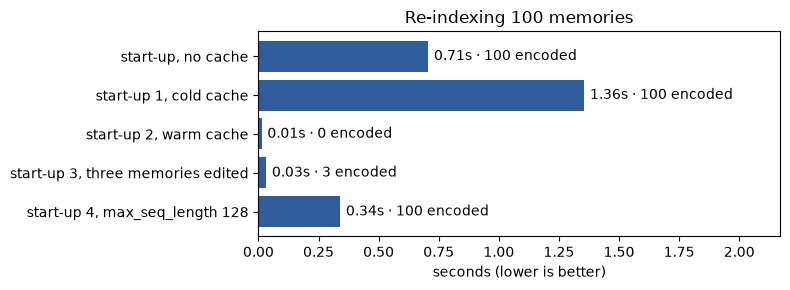

In [48]:
startups = results[results.step.str.startswith("start-up")]
labels = [
    f"{s:.2f}s · {n} encoded" for s, n in zip(startups.seconds, startups.encoder_runs)
]
figure, axis = plt.subplots(figsize=(8, 3))
bars = axis.barh(startups.step, startups.seconds, color="#2F5D9B")
axis.invert_yaxis()
axis.bar_label(bars, labels=labels, padding=4)
axis.set_xlabel("seconds (lower is better)")
axis.set_xlim(0, startups.seconds.max() * 1.6)
axis.set_title(f"Re-indexing {len(memory_texts)} memories")
plt.tight_layout()
plt.show()

## 6.3 · What the cache holds

Each `FLOAT32` vector of 384 dimensions takes 1,536 bytes, so a million cached texts need about 1.5 GB for
the vectors alone. The query counts this run's rows.

**What to watch:** more rows than distinct texts. The 100 original memories are stored under two
configurations (256 and 128 tokens), plus the three edited versions and the task.

In [49]:
print(
    f"{EMBED_DIM * 4:,} bytes per vector; a million texts ≈ {EMBED_DIM * 4 * 1e6 / 1e9:.1f} GB"
)
with conn.cursor() as cursor:
    cursor.execute(
        """
        SELECT COUNT(*), COUNT(DISTINCT text_sha256) FROM EC_EMBEDDING_CACHE
        WHERE namespace = :ns""",
        ns=RUN_ID,
    )
    rows, texts = cursor.fetchone()
print(rows, "cached vectors for", texts, "distinct texts")

1,536 bytes per vector; a million texts ≈ 1.5 GB
204 cached vectors for 104 distinct texts


## 6.4 · Forget a memory

A user asks the agent to forget issue number 10. `forget()` deletes the memory from the index **and**
every cached vector of its text, found through `text_sha256`, whatever configuration produced it. This
notebook scopes the purge to its own namespace; a production purge would cover every namespace that may
hold the text.

**What to watch:** two cached vectors are purged, one per configuration the text was encoded with.

In [50]:
FORGET_MEMORY = "DELETE FROM EC_AGENT_MEMORY WHERE namespace = :ns AND memory_id = :m"
PURGE_VECTORS = (
    "DELETE FROM EC_EMBEDDING_CACHE WHERE namespace = :ns AND text_sha256 = :h"
)


def forget(memory_id, text):
    """Delete a memory from the index and purge every cached vector of its text."""
    with conn.cursor() as cursor:
        cursor.execute(FORGET_MEMORY, ns=RUN_ID, m=memory_id)
        cursor.execute(PURGE_VECTORS, ns=RUN_ID, h=text_hash(text))
        purged = cursor.rowcount
    conn.commit()
    return purged


print("cached vectors purged:", forget(memories.instance_id[10], edited[10]))

cached vectors purged: 2


## 6.5 · Production notes

- **Batch everything.** One lookup query and one forward pass per batch. Per-text round trips can make a
  cache slower than no cache at all.
- **Use a stable namespace.** Name it after the agent deployment and, for private text, the owner.
  Sharing across workers is where most of the hits come from.
- **Treat concurrent inserts as hits.** A duplicate key means another worker already did the work.
- **Evict by age or last use.** Add a `last_used_at` column (updated in batches) or evict by `created_at`;
  edited memories leave orphaned rows behind.
- **Purge on forget.** Deleting a memory must delete its cached vectors in every namespace that may hold them.
- **Upgrade models deliberately.** A new model or revision is a new key space: re-index into a new index,
  switch over, then delete the old model's rows by `model` and `revision`.
- **Watch the hit rate.** A cache that rarely hits only adds latency; measure before and after.
- **Mind the storage.** 1,536 bytes per vector adds up. Oracle also supports `INT8` and `BINARY` vectors,
  but a quantised vector is a different vector, so the format belongs in the key too.

## 6.6 · Clean up this run

Delete this run's rows from both tables (the tables stay for the next run), then close the connections.

In [51]:
with conn.cursor() as cursor:
    cursor.execute("DELETE FROM EC_AGENT_MEMORY WHERE namespace = :ns", ns=RUN_ID)
    index_rows = cursor.rowcount
    cursor.execute("DELETE FROM EC_EMBEDDING_CACHE WHERE namespace = :ns", ns=RUN_ID)
    print("deleted", index_rows, "index rows and", cursor.rowcount, "cache rows")
conn.commit()
conn.close()
claude.close()

deleted 99 index rows and 202 cache rows


### Takeaways

- The warm start-up replaced every forward pass with one database query; only changed text was encoded again.
- Edits and configuration changes were handled by the key alone: no invalidation code ran.
- A hit returned exactly the vector the model would have produced, so retrieval, reranking and Claude
  behaved as they would without the cache.
- The cache is a rebuildable memo of the encoder. Episodic memory stays the source of truth, and
  forgetting a memory means purging its vectors too.